,Type Name,Double-Damage Count,Type Advantage Over,No Damage To
1,fighting,5,"normal, rock, steel, ice, dark",ghost
4,ground,5,"poison, rock, steel, fire, electric",flying
9,fire,4,"bug, steel, grass, ice",N/A
5,rock,4,"flying, bug, fire, ice",N/A
14,ice,4,"flying, ground, grass, dragon",N/A
17,fairy,3,"fighting, dragon, dark",N/A
8,steel,3,"rock, ice, fairy",N/A
6,bug,3,"grass, psychic, dark",N/A
10,water,3,"ground, rock, fire",N/A
2,flying,3,"fighting, bug, grass",N/A


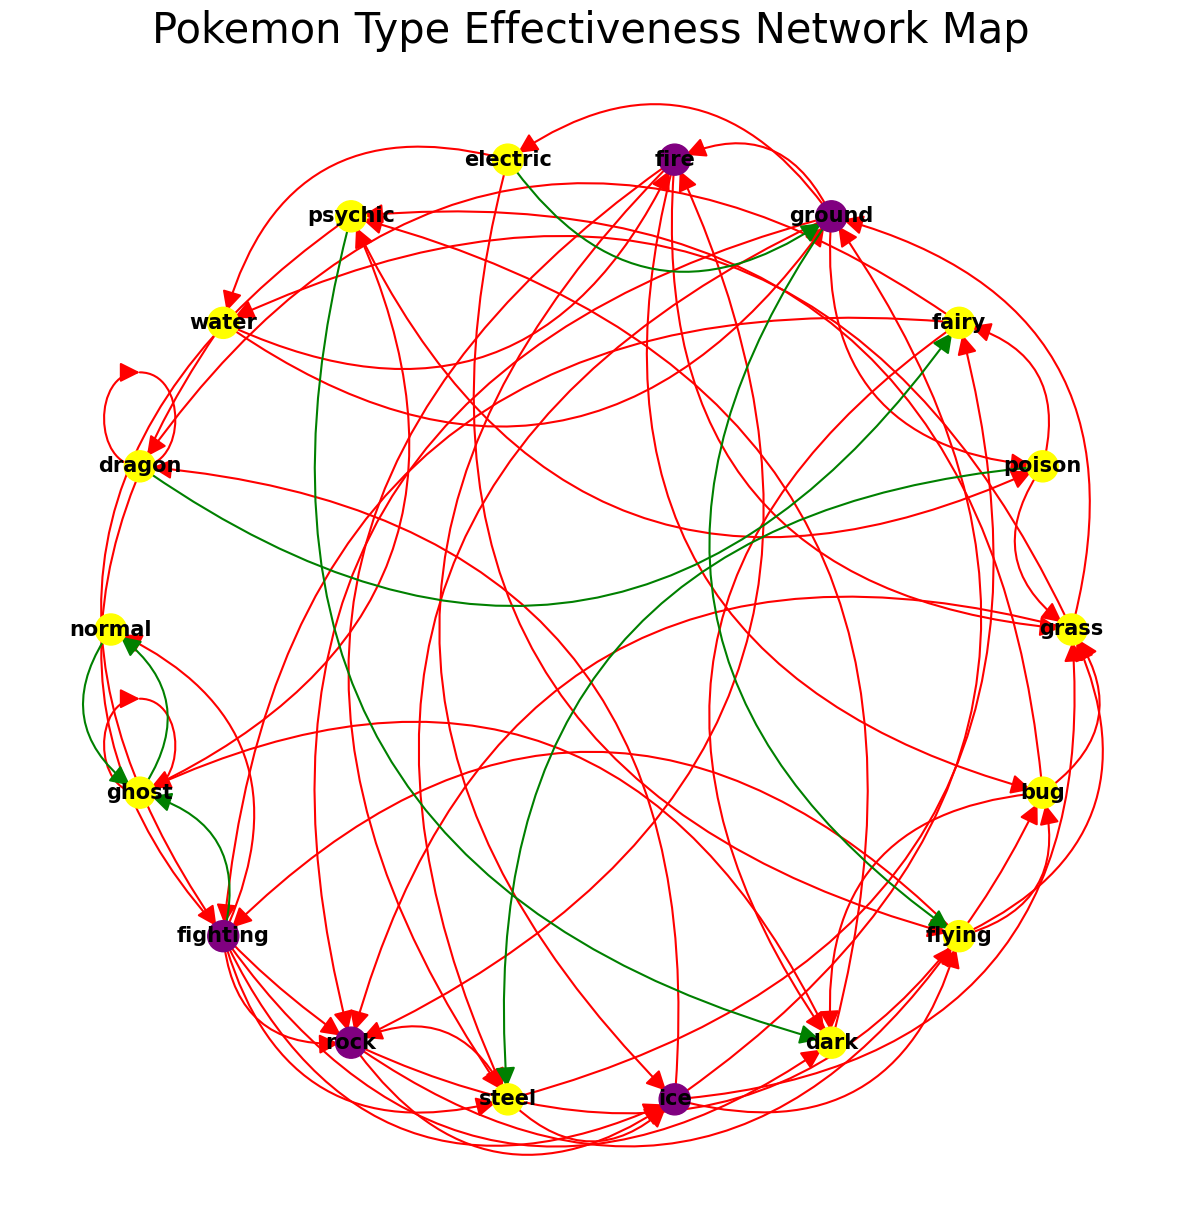

In [1]:
# IMPORTING NECESSARY LIBRARIES 
import requests
import json
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# REQUESTING AND ACQUIRING TYPE DATA FROM POKEAPI
type_response = requests.get("https://pokeapi.co/api/v2/type?limit=18")
type_data = json.loads(type_response.content)

# INITIALIZING TYPE LIST FOR PANDAS DATAFRAME
type_list = []

# INITIALIZING THE DIRECTED GRAPH FROM NETWORKX
g = nx.DiGraph()

# INITALIZING DICTIONARY TO TRACK TYPE ADVANTAGES 
double_damage_count = {}

for element in type_data['results']:
    type_name = element['name']
    
    detail_response = requests.get(element['url'])
    detail_data = detail_response.json()
    damage = detail_data['damage_relations']

    g.add_node(type_name)

    double_damage_count[type_name] = len(damage["double_damage_to"])
                                          
    for attack in damage['double_damage_to']:
        g.add_edge(type_name, attack['name'], color='red')

    #for attack in damage['half_damage_from']:
        #g.add_edge(type_name, attack['name'], color='blue')

    for attack in damage['no_damage_to']:
        g.add_edge(type_name, attack['name'], color='green')

    type_list.append({"Type Name": type_name,
            "Double-Damage Count": double_damage_count[type_name],
            "Type Advantage Over": ", ".join([attack['name'] for attack in damage["double_damage_to"]]) or "N/A",
            #"Reduced Damage From": ", ".join([attack['name'] for attack in damage["half_damage_from"]]) or "N/A",
            "No Damage To": ", ".join([attack['name'] for attack in damage["no_damage_to"]]) or "N/A"
            })

# CHANGING NODE COLORS IF A CERTAIN TYPE HAS 4+ TYPE ADVANTAGES (INDICATES HIGH STRENGTH AND VERSATILITY)
node_colors = []
for node in g.nodes():
    if double_damage_count.get(node, 0) >= 4:
        node_colors.append("purple")
    else:
        node_colors.append("yellow")

# DRAWING THE NETWORK MAP AND DISPLAYING IT ON A PLOT USING MATPLOTLIB
plt.figure(figsize=(15,15))
pos = nx.shell_layout(g)

nx.draw_networkx_nodes(g, pos, node_size=500, node_color=node_colors)
nx.draw_networkx_labels(g, pos, font_size=15, font_weight="bold")

double_edges = [(u, v) for u, v, d in g.edges(data=True) if d['color'] == 'red']
#resistant_edges = [(u, v) for u, v, d in g.edges(data=True) if d['color'] == 'blue']
immune_edges = [(u, v) for u, v, d in g.edges(data=True) if d['color'] == 'green']

nx.draw_networkx_edges(g, pos, edgelist=double_edges, edge_color="red", width=1.5, arrowstyle="-|>", arrowsize=30, connectionstyle='arc3,rad=0.5')
#nx.draw_networkx_edges(g, pos, edgelist=resistant_edges, edge_color="blue", width=1.5, arrowstyle="-|>", arrowsize=30, connectionstyle='arc3,rad=0.5')
nx.draw_networkx_edges(g, pos, edgelist=immune_edges, edge_color="green", width=1.5, arrowstyle="-|>", arrowsize=30, connectionstyle='arc3,rad=0.5')

plt.title("Pokemon Type Effectiveness Network Map", fontsize=30)
plt.axis("off")

# CREATING AND DISPLAYING THE DATAFRAME (TYPES WITH MOST ADVANTAGES AT TOP)
df = pd.DataFrame(type_list)
type_df = df.sort_values(by="Double-Damage Count", ascending=False)
type_df

In [2]:
out_degree = nx.out_degree_centrality(g)
sorted_out_degree = dict(sorted(out_degree.items(), key=lambda x: x[1], reverse=True))
for name, measure in list(sorted_out_degree.items()):
    print(f"{name}: {measure}")

fighting: 0.3529411764705882
ground: 0.3529411764705882
rock: 0.23529411764705882
ice: 0.23529411764705882
fire: 0.23529411764705882
ghost: 0.1764705882352941
steel: 0.1764705882352941
flying: 0.1764705882352941
bug: 0.1764705882352941
grass: 0.1764705882352941
poison: 0.1764705882352941
fairy: 0.1764705882352941
electric: 0.1764705882352941
psychic: 0.1764705882352941
water: 0.1764705882352941
dark: 0.11764705882352941
dragon: 0.11764705882352941
normal: 0.058823529411764705
